# 🪨 Granite Industry — Regression & Classification

| | |
|---|---|
| **Rows** | 5,500 |
| **Columns** | 11 (10 features + 1 ID-like) |
| **States** | Rajasthan · Tamil Nadu · Andhra Pradesh · Telangana · Karnataka · Gujarat |
| **Regression target** | `Net_Profit_Margin_Pct` (continuous) |
| **Classification target** | `Profitability_Class` (Low / Medium / High) |

**Notebook flow:**
```
Cell 1  Install & imports
Cell 2  Upload CSV
Cell 3  EDA — shape, stats, distributions, correlation
Cell 4  Preprocessing — missing values, outliers, encoding, scaling
Cell 5  ── REGRESSION ──  train 7 models, compare, best model PKL
Cell 6  Regression evaluation — plots, feature importance
Cell 7  ── CLASSIFICATION ──  train 6 models, compare, best model PKL
Cell 8  Classification evaluation — confusion matrix, ROC, report
Cell 9  Predict on custom input (regression + classification)
Cell 10 Download all PKL files
```

In [1]:
# ── Cell 1: Install & Imports ─────────────────────────────────────────
!pip install -q openpyxl scikit-learn pandas numpy matplotlib seaborn joblib imbalanced-learn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, re

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

# Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize

os.makedirs('models', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
print('✅ All imports done. models/ folder ready.')

✅ All imports done. models/ folder ready.


  Shape          : 5500 rows × 11 columns
  Missing values : 235
  Duplicate rows : 0

📋 Column Overview:
  State                               dtype=object   nulls=0     unique=6
  City                                dtype=object   nulls=0     unique=30
  Scale_of_Operation                  dtype=object   nulls=0     unique=3
  Monthly_Production_Tons             dtype=float64  nulls=0     unique=5468
  Machine_Utilization_Pct             dtype=float64  nulls=0     unique=3091
  Skilled_Labor_Pct                   dtype=float64  nulls=0     unique=3435
  Transport_Cost_Rs_per_Ton           dtype=float64  nulls=98    unique=5334
  Quality_Rejection_Rate_Pct          dtype=float64  nulls=137   unique=1204
  Avg_Selling_Price_Rs_sqm            dtype=float64  nulls=0     unique=5405
  Net_Profit_Margin_Pct               dtype=float64  nulls=0     unique=4769
  Profitability_Class                 dtype=object   nulls=0     unique=3

📊 Numeric Summary:
       Monthly_Production_Tons  Machin

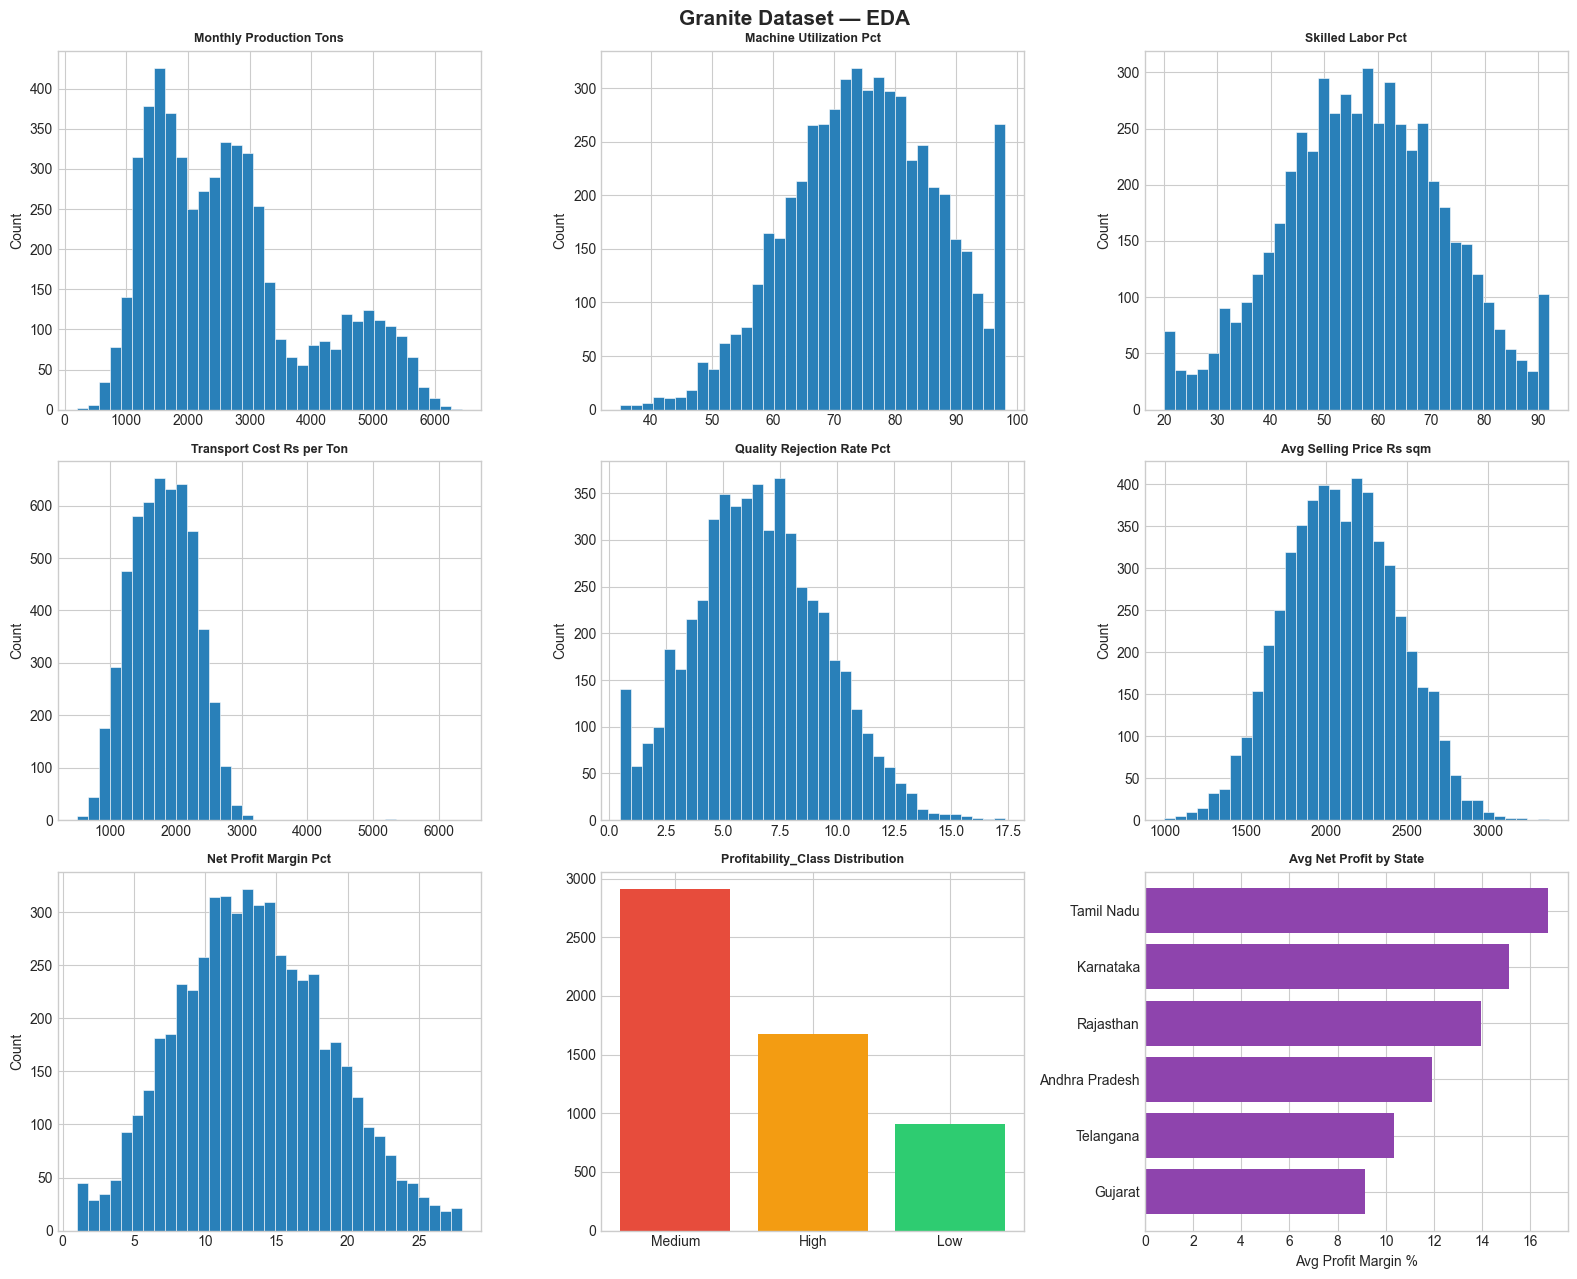

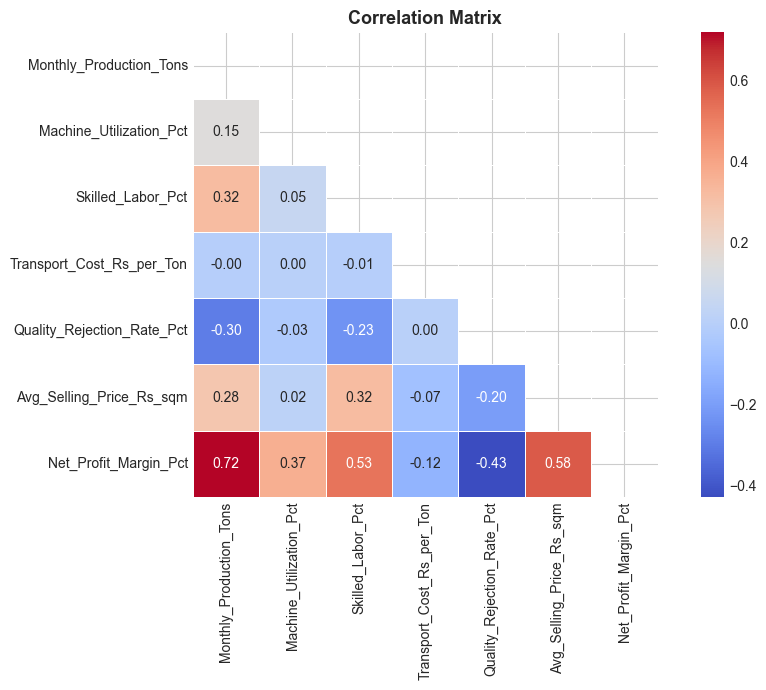

📊 Saved: eda_plots.png, correlation_heatmap.png


In [2]:
# ── Cell 3: EDA ────────────────────────────────────────────────────────
df = pd.read_csv('Granite_Industry_Dataset.csv')

print('='*60)
print(f'  Shape          : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'  Missing values : {df.isnull().sum().sum()}')
print(f'  Duplicate rows : {df.duplicated().sum()}')
print('='*60)

print('\n📋 Column Overview:')
for col in df.columns:
    dtype  = str(df[col].dtype)
    nulls  = df[col].isnull().sum()
    unique = df[col].nunique()
    print(f'  {col:<35} dtype={dtype:<8} nulls={nulls:<5} unique={unique}')

print('\n📊 Numeric Summary:')
print(df.describe().round(2).to_string())

print('\n📂 Categorical Values:')
for c in ['State','City','Scale_of_Operation','Profitability_Class']:
    print(f'  {c}: {df[c].value_counts().to_dict()}')

# ── Plots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle('Granite Dataset — EDA', fontsize=15, fontweight='bold')

num_cols = ['Monthly_Production_Tons','Machine_Utilization_Pct','Skilled_Labor_Pct',
            'Transport_Cost_Rs_per_Ton','Quality_Rejection_Rate_Pct',
            'Avg_Selling_Price_Rs_sqm','Net_Profit_Margin_Pct']

for ax, col in zip(axes.flatten()[:7], num_cols):
    ax.hist(df[col].dropna(), bins=35, color='#2980b9', edgecolor='white', linewidth=0.4)
    ax.set_title(col.replace('_',' '), fontsize=9, fontweight='bold')
    ax.set_ylabel('Count')

# Class distribution
cc = df['Profitability_Class'].value_counts()
axes[2,1].bar(cc.index, cc.values, color=['#e74c3c','#f39c12','#2ecc71'])
axes[2,1].set_title('Profitability_Class Distribution', fontsize=9, fontweight='bold')

# State-wise avg profit
sp = df.groupby('State')['Net_Profit_Margin_Pct'].mean().sort_values()
axes[2,2].barh(sp.index, sp.values, color='#8e44ad')
axes[2,2].set_title('Avg Net Profit by State', fontsize=9, fontweight='bold')
axes[2,2].set_xlabel('Avg Profit Margin %')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()

# Correlation heatmap
fig2, ax2 = plt.subplots(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax2, square=True, linewidths=0.5)
ax2.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('📊 Saved: eda_plots.png, correlation_heatmap.png')

In [3]:
# ── Cell 4: Preprocessing ─────────────────────────────────────────────
# Step 1 — Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)
print(f'After dedup: {df.shape}')

# Step 2 — Handle missing values
#   Quality_Rejection_Rate_Pct  → median impute (skewed numeric)
#   Transport_Cost_Rs_per_Ton   → median impute
for col in ['Quality_Rejection_Rate_Pct', 'Transport_Cost_Rs_per_Ton']:
    med = df[col].median()
    df[col].fillna(med, inplace=True)
    print(f'  Imputed {col} with median={med:.2f}')

# Step 3 — Outlier capping (IQR method on numeric columns)
num_cols = ['Monthly_Production_Tons','Machine_Utilization_Pct','Skilled_Labor_Pct',
            'Transport_Cost_Rs_per_Ton','Quality_Rejection_Rate_Pct',
            'Avg_Selling_Price_Rs_sqm']

print('\nOutlier capping (IQR 1.5x):')
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lo, hi)
    print(f'  {col:<35}  capped {n_out} outliers  [{lo:.1f}, {hi:.1f}]')

# Step 4 — Encode categoricals
# State & City → Label Encoding (many categories)
# Scale_of_Operation → Ordinal (Small < Medium < Large)

le_state = LabelEncoder()
le_city  = LabelEncoder()
df['State_enc'] = le_state.fit_transform(df['State'])
df['City_enc']  = le_city.fit_transform(df['City'])

oe_scale = OrdinalEncoder(categories=[['Small','Medium','Large']])
df['Scale_enc'] = oe_scale.fit_transform(df[['Scale_of_Operation']]).astype(int)

# Classification label encoder
le_class = LabelEncoder()  # Low=0, Medium=1, High=2
df['Profit_Class_enc'] = le_class.fit_transform(df['Profitability_Class'])
print(f'\nClass mapping: {dict(zip(le_class.classes_, le_class.transform(le_class.classes_)))}')

# Step 5 — Build final feature matrix
FEATURES = ['State_enc','City_enc','Scale_enc',
            'Monthly_Production_Tons','Machine_Utilization_Pct',
            'Skilled_Labor_Pct','Transport_Cost_Rs_per_Ton',
            'Quality_Rejection_Rate_Pct','Avg_Selling_Price_Rs_sqm']

REG_TARGET = 'Net_Profit_Margin_Pct'
CLS_TARGET = 'Profit_Class_enc'

X  = df[FEATURES]
y_reg = df[REG_TARGET]
y_cls = df[CLS_TARGET]

# Step 6 — Scale
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

# Step 7 — Split
X_tr, X_te, yr_tr, yr_te, yc_tr, yc_te = train_test_split(
    X_sc, y_reg, y_cls, test_size=0.2, random_state=SEED, stratify=y_cls)

print(f'\n✅ Preprocessing complete')
print(f'   Train: {X_tr.shape[0]}  |  Test: {X_te.shape[0]}')
print(f'   Features: {X_tr.shape[1]}')

# Save preprocessors
joblib.dump(scaler,   'models/scaler.pkl')
joblib.dump(le_state, 'models/le_state.pkl')
joblib.dump(le_city,  'models/le_city.pkl')
joblib.dump(oe_scale, 'models/oe_scale.pkl')
joblib.dump(le_class, 'models/le_class.pkl')
joblib.dump(FEATURES, 'models/feature_names.pkl')
print('   💾 All preprocessors saved in models/')

After dedup: (5500, 11)
  Imputed Quality_Rejection_Rate_Pct with median=6.48
  Imputed Transport_Cost_Rs_per_Ton with median=1800.49

Outlier capping (IQR 1.5x):
  Monthly_Production_Tons              capped 61 outliers  [-800.2, 5662.9]
  Machine_Utilization_Pct              capped 22 outliers  [41.0, 109.6]
  Skilled_Labor_Pct                    capped 0 outliers  [15.0, 99.7]
  Transport_Cost_Rs_per_Ton            capped 10 outliers  [389.8, 3196.3]
  Quality_Rejection_Rate_Pct           capped 31 outliers  [-1.0, 14.0]
  Avg_Selling_Price_Rs_sqm             capped 15 outliers  [1102.2, 3074.8]

Class mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

✅ Preprocessing complete
   Train: 4400  |  Test: 1100
   Features: 9
   💾 All preprocessors saved in models/


In [4]:
print("Missing values in X:")
print(pd.DataFrame(X_tr).isna().sum())

Missing values in X:
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64


In [5]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_tr = imputer.fit_transform(X_tr)
X_te = imputer.transform(X_te)

In [6]:
# ── Cell 5: REGRESSION — Train 7 Models ──────────────────────────────
REG_MODELS = {
    'Linear Regression':  LinearRegression(),
    'Ridge':              Ridge(alpha=1.0, random_state=SEED),
    'Lasso':              Lasso(alpha=0.05, max_iter=5000, random_state=SEED),
    'Random Forest':      RandomForestRegressor(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, learning_rate=0.08, max_depth=4, random_state=SEED),
    'Extra Trees':        ExtraTreesRegressor(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1),
    'SVR':                SVR(C=2.0, epsilon=0.1, kernel='rbf'),
}

reg_results = []
reg_trained = {}

print('REGRESSION: Net_Profit_Margin_Pct')
print('='*68)
print(f'  {"Model":<22} {"R²":>8} {"RMSE":>8} {"MAE":>8} {"MAPE%":>8}')
print('-'*68)

for name, mdl in REG_MODELS.items():
    mdl.fit(X_tr, yr_tr)
    yp = mdl.predict(X_te)
    r2   = r2_score(yr_te, yp)
    rmse = np.sqrt(mean_squared_error(yr_te, yp))
    mae  = mean_absolute_error(yr_te, yp)
    mape = np.mean(np.abs((yr_te - yp) / (np.abs(yr_te)+1e-9))) * 100
    reg_results.append({'Model':name,'R²':round(r2,4),'RMSE':round(rmse,4),'MAE':round(mae,4),'MAPE(%)':round(mape,2)})
    reg_trained[name] = mdl
    print(f'  {name:<22} {r2:>8.4f} {rmse:>8.4f} {mae:>8.4f} {mape:>8.2f}%')

print('='*68)
reg_df = pd.DataFrame(reg_results).sort_values('R²', ascending=False).reset_index(drop=True)
BEST_REG_NAME  = reg_df.iloc[0]['Model']
BEST_REG_MODEL = reg_trained[BEST_REG_NAME]

print(f'\n🏆 Best Regression Model : {BEST_REG_NAME}')
print(f'   R²   : {reg_df.iloc[0]["R²"]}')
print(f'   RMSE : {reg_df.iloc[0]["RMSE"]}')
print(f'   MAE  : {reg_df.iloc[0]["MAE"]}')

# 5-fold CV
cv = cross_val_score(BEST_REG_MODEL, X_tr, yr_tr, cv=5, scoring='r2')
print(f'\n5-Fold CV R² : {cv.round(4)} → mean={cv.mean():.4f} ± {cv.std():.4f}')

# Save best regression model
reg_path = f'models/best_reg_{BEST_REG_NAME.replace(" ","_")}.pkl'
joblib.dump(BEST_REG_MODEL, reg_path)
# Save all regression models
for n, m in reg_trained.items():
    joblib.dump(m, f'models/reg_{n.replace(" ","_")}.pkl')
print(f'\n💾 Saved: {reg_path}  (+ all 7 reg models)')

REGRESSION: Net_Profit_Margin_Pct
  Model                        R²     RMSE      MAE    MAPE%
--------------------------------------------------------------------
  Linear Regression        0.8226   2.1864   1.7288    18.73%
  Ridge                    0.8226   2.1865   1.7289    18.73%
  Lasso                    0.8222   2.1886   1.7286    18.89%
  Random Forest            0.8165   2.2239   1.7447    19.49%
  Gradient Boosting        0.8506   2.0067   1.5885    17.04%
  Extra Trees              0.8226   2.1863   1.7258    19.53%
  SVR                      0.8403   2.0744   1.6464    18.01%

🏆 Best Regression Model : Gradient Boosting
   R²   : 0.8506
   RMSE : 2.0067
   MAE  : 1.5885

5-Fold CV R² : [0.8537 0.852  0.8441 0.8562 0.8601] → mean=0.8532 ± 0.0053

💾 Saved: models/best_reg_Gradient_Boosting.pkl  (+ all 7 reg models)


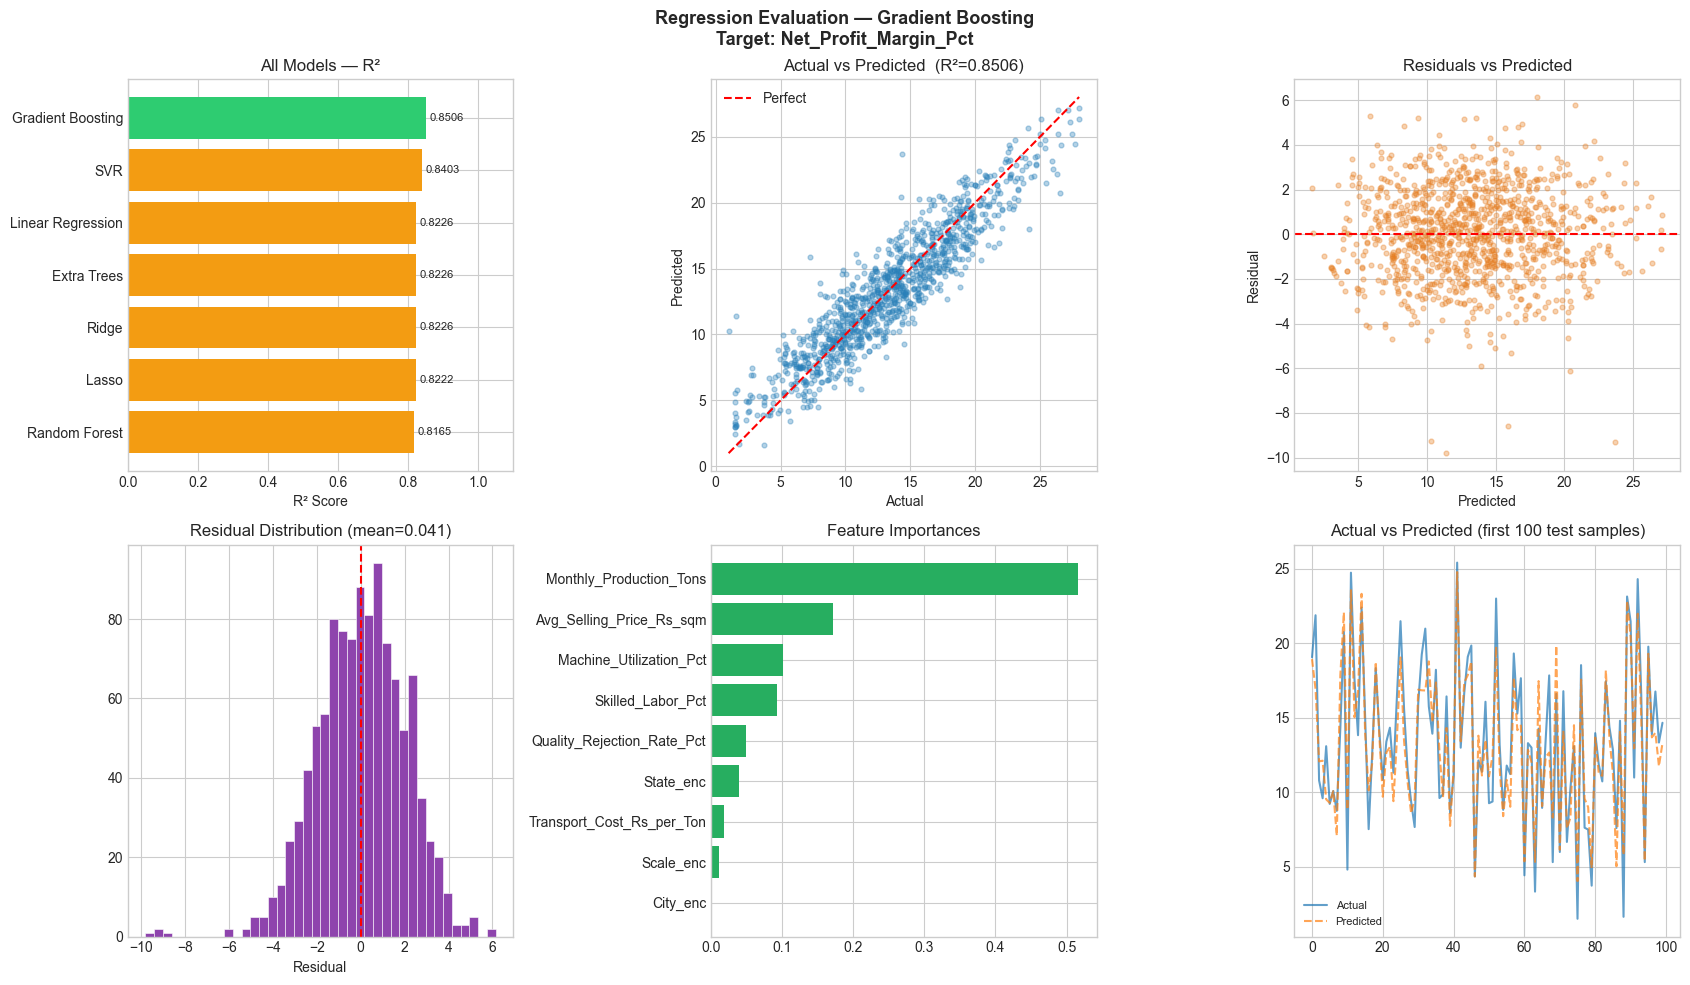

📊 Saved: regression_evaluation.png

Full Regression Leaderboard:
            Model     R²   RMSE    MAE  MAPE(%)
Gradient Boosting 0.8506 2.0067 1.5885    17.04
              SVR 0.8403 2.0744 1.6464    18.01
Linear Regression 0.8226 2.1864 1.7288    18.73
      Extra Trees 0.8226 2.1863 1.7258    19.53
            Ridge 0.8226 2.1865 1.7289    18.73
            Lasso 0.8222 2.1886 1.7286    18.89
    Random Forest 0.8165 2.2239 1.7447    19.49


In [7]:
# ── Cell 6: Regression Evaluation & Plots ────────────────────────────
yp_best = BEST_REG_MODEL.predict(X_te)
residuals = yr_te.values - yp_best

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(f'Regression Evaluation — {BEST_REG_NAME}\nTarget: Net_Profit_Margin_Pct', fontsize=13, fontweight='bold')

# 1. Model comparison R²
colors_r2 = ['#2ecc71' if r>=0.85 else '#f39c12' if r>=0.70 else '#e74c3c' for r in reg_df['R²']]
b = axes[0,0].barh(reg_df['Model'], reg_df['R²'], color=colors_r2)
axes[0,0].set_xlabel('R² Score'); axes[0,0].set_title('All Models — R²')
axes[0,0].set_xlim(0, 1.1); axes[0,0].invert_yaxis()
for bar, v in zip(b, reg_df['R²']):
    axes[0,0].text(v+0.01, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=8)

# 2. Actual vs Predicted
axes[0,1].scatter(yr_te, yp_best, alpha=0.35, s=12, color='#2980b9')
mn, mx = yr_te.min(), yr_te.max()
axes[0,1].plot([mn,mx],[mn,mx],'r--',lw=1.5,label='Perfect')
axes[0,1].set_xlabel('Actual'); axes[0,1].set_ylabel('Predicted')
axes[0,1].set_title(f'Actual vs Predicted  (R²={r2_score(yr_te,yp_best):.4f})')
axes[0,1].legend()

# 3. Residuals vs Predicted
axes[0,2].scatter(yp_best, residuals, alpha=0.35, s=12, color='#e67e22')
axes[0,2].axhline(0, color='red', lw=1.5, ls='--')
axes[0,2].set_xlabel('Predicted'); axes[0,2].set_ylabel('Residual')
axes[0,2].set_title('Residuals vs Predicted')

# 4. Residual histogram
axes[1,0].hist(residuals, bins=40, color='#8e44ad', edgecolor='white', lw=0.4)
axes[1,0].axvline(0, color='red', lw=1.5, ls='--')
axes[1,0].set_xlabel('Residual'); axes[1,0].set_title(f'Residual Distribution (mean={residuals.mean():.3f})')

# 5. Feature importance
feat_names = FEATURES
if hasattr(BEST_REG_MODEL,'feature_importances_'):
    imp = pd.Series(BEST_REG_MODEL.feature_importances_, index=feat_names).sort_values()
    axes[1,1].barh(imp.index, imp.values, color='#27ae60')
    axes[1,1].set_title('Feature Importances')
elif hasattr(BEST_REG_MODEL,'coef_'):
    coef = pd.Series(np.abs(BEST_REG_MODEL.coef_), index=feat_names).sort_values()
    axes[1,1].barh(coef.index, coef.values, color='#2980b9')
    axes[1,1].set_title('|Coefficients|')
else:
    axes[1,1].text(0.5,0.5,'N/A for SVR',ha='center',va='center',transform=axes[1,1].transAxes)

# 6. Prediction vs index sample
idx = range(100)
axes[1,2].plot(list(idx), yr_te.values[:100], label='Actual', alpha=0.7, lw=1.5)
axes[1,2].plot(list(idx), yp_best[:100],      label='Predicted', alpha=0.7, lw=1.5, ls='--')
axes[1,2].set_title('Actual vs Predicted (first 100 test samples)')
axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('regression_evaluation.png', dpi=130, bbox_inches='tight')
plt.show()
print('📊 Saved: regression_evaluation.png')
print('\nFull Regression Leaderboard:')
print(reg_df.to_string(index=False))

In [8]:
# ── Cell 7: CLASSIFICATION — Train 6 Models ──────────────────────────
CLS_MODELS = {
    'Logistic Regression':  LogisticRegression(max_iter=500, C=1.0, random_state=SEED),
    'Decision Tree':        DecisionTreeClassifier(max_depth=8, random_state=SEED),
    'Random Forest':        RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, learning_rate=0.08, max_depth=4, random_state=SEED),
    'SVC':                  SVC(C=1.5, kernel='rbf', probability=True, random_state=SEED),
    'KNN':                  KNeighborsClassifier(n_neighbors=7),
}

cls_results = []
cls_trained = {}

print('CLASSIFICATION: Profitability_Class  (Low / Medium / High)')
print('='*65)
print(f'  {"Model":<22} {"Accuracy":>10} {"Macro-F1":>10} {"AUC-OvR":>10}')
print('-'*65)

classes = le_class.classes_
y_bin   = label_binarize(yc_te, classes=range(len(classes)))

for name, mdl in CLS_MODELS.items():
    mdl.fit(X_tr, yc_tr)
    yp  = mdl.predict(X_te)
    ypp = mdl.predict_proba(X_te)
    acc = accuracy_score(yc_te, yp)
    from sklearn.metrics import f1_score
    f1  = f1_score(yc_te, yp, average='macro')
    auc = roc_auc_score(y_bin, ypp, multi_class='ovr', average='macro')
    cls_results.append({'Model':name,'Accuracy':round(acc,4),'Macro-F1':round(f1,4),'AUC-OvR':round(auc,4)})
    cls_trained[name] = mdl
    print(f'  {name:<22} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f}')

print('='*65)
cls_df = pd.DataFrame(cls_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
BEST_CLS_NAME  = cls_df.iloc[0]['Model']
BEST_CLS_MODEL = cls_trained[BEST_CLS_NAME]

print(f'\n🏆 Best Classification Model : {BEST_CLS_NAME}')
print(f'   Accuracy : {cls_df.iloc[0]["Accuracy"]}')
print(f'   Macro-F1 : {cls_df.iloc[0]["Macro-F1"]}')
print(f'   AUC-OvR  : {cls_df.iloc[0]["AUC-OvR"]}')

print(f'\nDetailed Classification Report ({BEST_CLS_NAME}):')
print(classification_report(yc_te, BEST_CLS_MODEL.predict(X_te), target_names=classes))

# Save best + all
cls_path = f'models/best_cls_{BEST_CLS_NAME.replace(" ","_")}.pkl'
joblib.dump(BEST_CLS_MODEL, cls_path)
for n, m in cls_trained.items():
    joblib.dump(m, f'models/cls_{n.replace(" ","_")}.pkl')
print(f'\n💾 Saved: {cls_path}  (+ all 6 cls models)')

CLASSIFICATION: Profitability_Class  (Low / Medium / High)
  Model                    Accuracy   Macro-F1    AUC-OvR
-----------------------------------------------------------------
  Logistic Regression        0.7718     0.7366     0.9021
  Decision Tree              0.7073     0.6764     0.8193
  Random Forest              0.7682     0.7343     0.8928
  Gradient Boosting          0.7709     0.7448     0.8946
  SVC                        0.7800     0.7533     0.9074
  KNN                        0.7573     0.7288     0.8776

🏆 Best Classification Model : SVC
   Accuracy : 0.78
   Macro-F1 : 0.7533
   AUC-OvR  : 0.9074

Detailed Classification Report (SVC):
              precision    recall  f1-score   support

        High       0.82      0.74      0.78       336
         Low       0.76      0.60      0.67       182
      Medium       0.77      0.86      0.81       582

    accuracy                           0.78      1100
   macro avg       0.78      0.73      0.75      1100
weighted

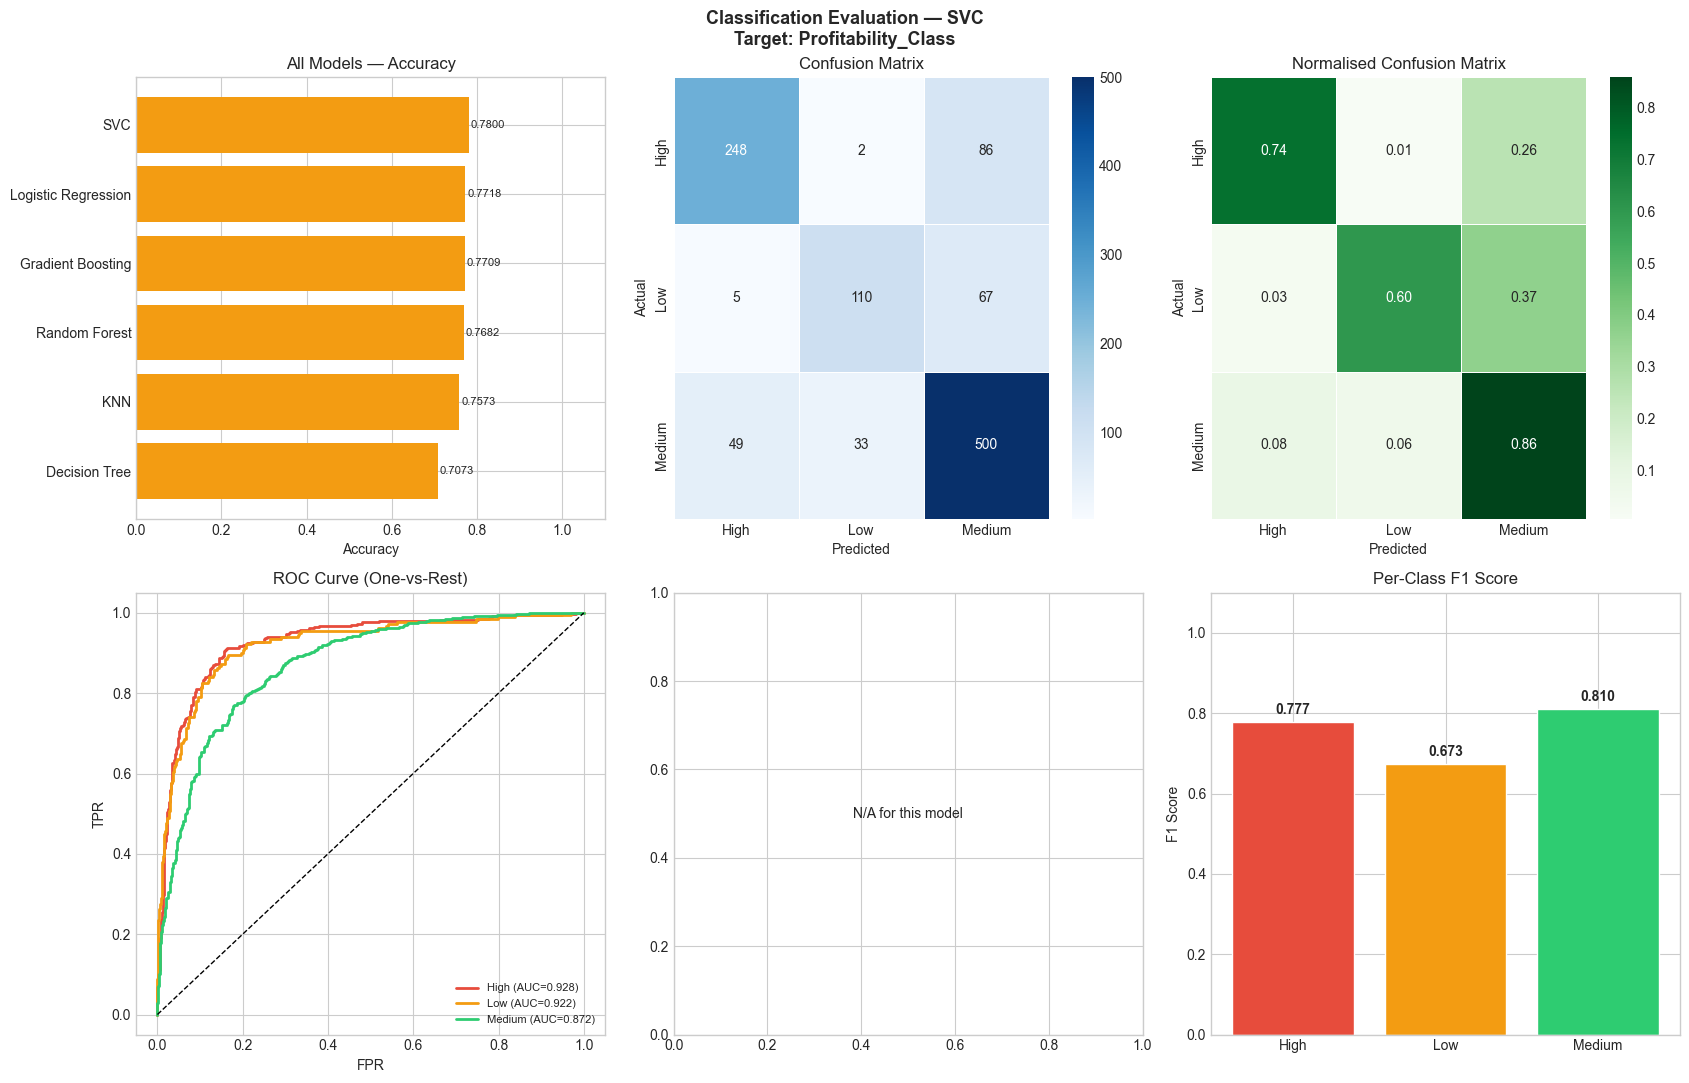

📊 Saved: classification_evaluation.png

Classification Leaderboard:
              Model  Accuracy  Macro-F1  AUC-OvR
                SVC    0.7800    0.7533   0.9074
Logistic Regression    0.7718    0.7366   0.9021
  Gradient Boosting    0.7709    0.7448   0.8946
      Random Forest    0.7682    0.7343   0.8928
                KNN    0.7573    0.7288   0.8776
      Decision Tree    0.7073    0.6764   0.8193


In [9]:
# ── Cell 8: Classification Evaluation & Plots ─────────────────────────
yp_cls_best  = BEST_CLS_MODEL.predict(X_te)
ypp_cls_best = BEST_CLS_MODEL.predict_proba(X_te)
classes      = le_class.classes_
y_bin        = label_binarize(yc_te, classes=range(len(classes)))

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
fig.suptitle(f'Classification Evaluation — {BEST_CLS_NAME}\nTarget: Profitability_Class', fontsize=13, fontweight='bold')

# 1. Accuracy comparison
colors_acc = ['#2ecc71' if a>=0.85 else '#f39c12' if a>=0.70 else '#e74c3c' for a in cls_df['Accuracy']]
b = axes[0,0].barh(cls_df['Model'], cls_df['Accuracy'], color=colors_acc)
axes[0,0].set_xlabel('Accuracy'); axes[0,0].set_title('All Models — Accuracy'); axes[0,0].invert_yaxis()
axes[0,0].set_xlim(0, 1.1)
for bar, v in zip(b, cls_df['Accuracy']):
    axes[0,0].text(v+0.005, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=8)

# 2. Confusion matrix
cm = confusion_matrix(yc_te, yp_cls_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,1],
            xticklabels=classes, yticklabels=classes, linewidths=0.5)
axes[0,1].set_xlabel('Predicted'); axes[0,1].set_ylabel('Actual')
axes[0,1].set_title('Confusion Matrix')

# 3. Normalised confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[0,2],
            xticklabels=classes, yticklabels=classes, linewidths=0.5)
axes[0,2].set_xlabel('Predicted'); axes[0,2].set_ylabel('Actual')
axes[0,2].set_title('Normalised Confusion Matrix')

# 4. ROC curves (OvR)
colors_roc = ['#e74c3c','#f39c12','#2ecc71']
for i, (cls_name, c) in enumerate(zip(classes, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], ypp_cls_best[:, i])
    auc_score   = roc_auc_score(y_bin[:, i], ypp_cls_best[:, i])
    axes[1,0].plot(fpr, tpr, color=c, lw=2, label=f'{cls_name} (AUC={auc_score:.3f})')
axes[1,0].plot([0,1],[0,1],'k--',lw=1)
axes[1,0].set_xlabel('FPR'); axes[1,0].set_ylabel('TPR')
axes[1,0].set_title('ROC Curve (One-vs-Rest)'); axes[1,0].legend(fontsize=8)

# 5. Feature importance (classification)
if hasattr(BEST_CLS_MODEL,'feature_importances_'):
    imp_c = pd.Series(BEST_CLS_MODEL.feature_importances_, index=FEATURES).sort_values()
    axes[1,1].barh(imp_c.index, imp_c.values, color='#8e44ad')
    axes[1,1].set_title('Feature Importances (Classification)')
elif hasattr(BEST_CLS_MODEL,'coef_'):
    coef_c = pd.Series(np.abs(BEST_CLS_MODEL.coef_).mean(axis=0), index=FEATURES).sort_values()
    axes[1,1].barh(coef_c.index, coef_c.values, color='#2980b9')
    axes[1,1].set_title('|Coefficients| (Classification)')
else:
    axes[1,1].text(0.5,0.5,'N/A for this model',ha='center',va='center',transform=axes[1,1].transAxes)

# 6. Per-class F1
from sklearn.metrics import f1_score
f1_per_class = f1_score(yc_te, yp_cls_best, average=None)
axes[1,2].bar(classes, f1_per_class, color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='white')
axes[1,2].set_ylim(0,1.1); axes[1,2].set_ylabel('F1 Score')
axes[1,2].set_title('Per-Class F1 Score')
for i, v in enumerate(f1_per_class):
    axes[1,2].text(i, v+0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('classification_evaluation.png', dpi=130, bbox_inches='tight')
plt.show()
print('📊 Saved: classification_evaluation.png')
print('\nClassification Leaderboard:')
print(cls_df.to_string(index=False))

In [10]:
# ── Cell 9: Predict on Custom Input ──────────────────────────────────
# ✏️  Edit the values below then run the cell

CUSTOM = {
    'State':                        'Tamil Nadu',   # Rajasthan / Tamil Nadu / Andhra Pradesh / Telangana / Karnataka / Gujarat
    'City':                         'Salem',        # any city from that state
    'Scale_of_Operation':           'Medium',       # Small / Medium / Large
    'Monthly_Production_Tons':      2800.0,
    'Machine_Utilization_Pct':      78.0,
    'Skilled_Labor_Pct':            65.0,
    'Transport_Cost_Rs_per_Ton':    1500.0,
    'Quality_Rejection_Rate_Pct':   4.5,
    'Avg_Selling_Price_Rs_sqm':     2300.0,
}

# ── Encode ──────────────────────────────────────────────────────────
def safe_encode(le, val):
    if val in le.classes_:
        return le.transform([val])[0]
    print(f'  Warning: "{val}" not seen during training. Using 0.')
    return 0

row = {
    'State_enc':                  safe_encode(le_state, CUSTOM['State']),
    'City_enc':                   safe_encode(le_city,  CUSTOM['City']),
    'Scale_enc':                  int(oe_scale.transform([[CUSTOM['Scale_of_Operation']]])[0][0]),
    'Monthly_Production_Tons':    CUSTOM['Monthly_Production_Tons'],
    'Machine_Utilization_Pct':    CUSTOM['Machine_Utilization_Pct'],
    'Skilled_Labor_Pct':          CUSTOM['Skilled_Labor_Pct'],
    'Transport_Cost_Rs_per_Ton':  CUSTOM['Transport_Cost_Rs_per_Ton'],
    'Quality_Rejection_Rate_Pct': CUSTOM['Quality_Rejection_Rate_Pct'],
    'Avg_Selling_Price_Rs_sqm':   CUSTOM['Avg_Selling_Price_Rs_sqm'],
}

row_df  = pd.DataFrame([row])[FEATURES]
row_sc  = scaler.transform(row_df)

# ── Regression prediction ──────────────────────────────────────────
reg_pred  = BEST_REG_MODEL.predict(row_sc)[0]
pct_rank  = (reg_pred - y_reg.min()) / (y_reg.max() - y_reg.min()) * 100

# ── Classification prediction ──────────────────────────────────────
cls_pred  = BEST_CLS_MODEL.predict(row_sc)[0]
cls_proba = BEST_CLS_MODEL.predict_proba(row_sc)[0]
cls_label = le_class.inverse_transform([cls_pred])[0]

print('='*55)
print('  INPUT SUMMARY')
print('='*55)
for k, v in CUSTOM.items():
    print(f'  {k:<35}: {v}')
print()
print('='*55)
print('  REGRESSION  →  Net_Profit_Margin_Pct')
print('='*55)
print(f'  Predicted Margin    : {reg_pred:.3f} %')
print(f'  Dataset Range       : {y_reg.min():.2f} → {y_reg.max():.2f}')
print(f'  Approx Percentile   : {pct_rank:.1f}th')
print(f'  Dataset Median      : {y_reg.median():.2f}')
print()
print('='*55)
print('  CLASSIFICATION  →  Profitability_Class')
print('='*55)
print(f'  Predicted Class     : {cls_label}')
print(f'  Class Probabilities :')
for lbl, prob in zip(le_class.classes_, cls_proba):
    bar = '█' * int(prob * 30)
    print(f'    {lbl:<8} {prob:.4f}  {bar}')

  INPUT SUMMARY
  State                              : Tamil Nadu
  City                               : Salem
  Scale_of_Operation                 : Medium
  Monthly_Production_Tons            : 2800.0
  Machine_Utilization_Pct            : 78.0
  Skilled_Labor_Pct                  : 65.0
  Transport_Cost_Rs_per_Ton          : 1500.0
  Quality_Rejection_Rate_Pct         : 4.5
  Avg_Selling_Price_Rs_sqm           : 2300.0

  REGRESSION  →  Net_Profit_Margin_Pct
  Predicted Margin    : 18.538 %
  Dataset Range       : 1.00 → 28.00
  Approx Percentile   : 65.0th
  Dataset Median      : 13.17

  CLASSIFICATION  →  Profitability_Class
  Predicted Class     : High
  Class Probabilities :
    High     0.8490  █████████████████████████
    Low      0.0042  
    Medium   0.1467  ████


In [11]:
# ── Cell 10: Save Metadata & All PKL Files (VS Code / Local) ──────────
import shutil

# Save metadata
metadata = {
    'features':          FEATURES,
    'reg_target':        REG_TARGET,
    'cls_target':        'Profitability_Class',
    'best_reg_model':    BEST_REG_NAME,
    'best_cls_model':    BEST_CLS_NAME,
    'reg_r2':            reg_df.iloc[0]['R²'],
    'reg_rmse':          reg_df.iloc[0]['RMSE'],
    'cls_accuracy':      cls_df.iloc[0]['Accuracy'],
    'cls_f1_macro':      cls_df.iloc[0]['Macro-F1'],
    'classes':           list(le_class.classes_),
    'states':            list(le_state.classes_),
    'cities':            list(le_city.classes_),
}
joblib.dump(metadata, 'models/metadata.pkl')

# Zip models folder into current working directory
shutil.make_archive('granite_models', 'zip', 'models')

# Print location of all saved files
print('✅ All PKL files saved in:', os.path.abspath('models'))
print()
print('📁 models/ contents:')
for f in sorted(os.listdir('models')):
    sz  = os.path.getsize(os.path.join('models', f)) / 1024
    tag = ''
    if 'best_reg' in f:   tag = '  ← BEST REGRESSION MODEL'
    elif 'best_cls' in f: tag = '  ← BEST CLASSIFICATION MODEL'
    elif 'scaler'   in f: tag = '  ← StandardScaler'
    elif 'metadata' in f: tag = '  ← metadata (features, scores, class names)'
    elif 'le_state' in f: tag = '  ← State LabelEncoder'
    elif 'le_city'  in f: tag = '  ← City LabelEncoder'
    elif 'le_class' in f: tag = '  ← Class LabelEncoder'
    elif 'oe_scale' in f: tag = '  ← Scale OrdinalEncoder'
    print(f'  {f:<55} ({sz:>7.1f} KB){tag}')

print()
print('📦 ZIP saved at:', os.path.abspath('granite_models.zip'))
print()
print('📊 Plots saved at:')
for png in ['eda_plots.png', 'correlation_heatmap.png',
            'regression_evaluation.png', 'classification_evaluation.png']:
    if os.path.exists(png):
        print(f'  {os.path.abspath(png)}')

print()
print('='*60)
print('  SUMMARY')
print('='*60)
print(f'  Best Regression Model    : {BEST_REG_NAME}')
print(f'  R² Score                 : {reg_df.iloc[0]["R²"]}')
print(f'  RMSE                     : {reg_df.iloc[0]["RMSE"]}')
print()
print(f'  Best Classification Model: {BEST_CLS_NAME}')
print(f'  Accuracy                 : {cls_df.iloc[0]["Accuracy"]}')
print(f'  Macro-F1                 : {cls_df.iloc[0]["Macro-F1"]}')
print('='*60)
print()
print('To load models in your Streamlit app or any script:')
print()
best_reg_file = f'best_reg_{BEST_REG_NAME.replace(" ", "_")}.pkl'
best_cls_file = f'best_cls_{BEST_CLS_NAME.replace(" ", "_")}.pkl'
print(f"import joblib")
print(f"meta     = joblib.load('models/metadata.pkl')")
print(f"reg_mdl  = joblib.load('models/{best_reg_file}')")
print(f"cls_mdl  = joblib.load('models/{best_cls_file}')")
print(f"scaler   = joblib.load('models/scaler.pkl')")
print(f"le_state = joblib.load('models/le_state.pkl')")
print(f"le_city  = joblib.load('models/le_city.pkl')")
print(f"oe_scale = joblib.load('models/oe_scale.pkl')")
print(f"le_class = joblib.load('models/le_class.pkl')")

✅ All PKL files saved in: f:\Manusri\Project Team - 1\models

📁 models/ contents:
  best_cls_SVC.pkl                                        (  244.5 KB)  ← BEST CLASSIFICATION MODEL
  best_reg_Gradient_Boosting.pkl                          (  479.7 KB)  ← BEST REGRESSION MODEL
  cls_Decision_Tree.pkl                                   (   32.3 KB)
  cls_Gradient_Boosting.pkl                               ( 1362.9 KB)
  cls_KNN.pkl                                             (  732.7 KB)
  cls_Logistic_Regression.pkl                             (    1.1 KB)
  cls_Random_Forest.pkl                                   (11192.3 KB)
  cls_SVC.pkl                                             (  244.5 KB)
  feature_names.pkl                                       (    0.2 KB)
  le_city.pkl                                             (    0.8 KB)  ← City LabelEncoder
  le_class.pkl                                            (    0.5 KB)  ← Class LabelEncoder
  le_state.pkl                          